<h1 style="text-align:center;">Análise Exploratória de Dados (EDA) – Base de Artigos</h1>

### 1. Carregando a base de Dados

In [1]:
import pandas as pd

df = pd.read_csv('../data/articles.csv')

### 2. Analise inicial
#### 2.1 Quantidade de linhas para serem analisadas

In [2]:
# mostra a quantidade de linhas e colunas do DataFrame
df.shape

(167053, 6)

#### 2.2 Identificando valores nulos na coluna text

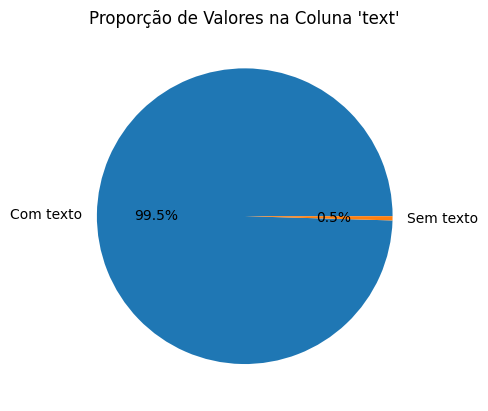

In [3]:
import matplotlib.pyplot as plt

# Calcula a porcentagem de valores nulos na coluna 'text'
total_linhas = len(df)
textos_nulo = df['text'].isnull().sum()
porcentagem_texto_nulo = (textos_nulo / total_linhas) * 100
porcentagem_texto_não_nulo = 100 - porcentagem_texto_nulo


plt.figure()
plt.pie(
    [porcentagem_texto_não_nulo, porcentagem_texto_nulo],
    labels=['Com texto', 'Sem texto'],
    autopct='%1.1f%%'
)

plt.title("Proporção de Valores na Coluna 'text'")
plt.show()

#### 2.3 Verificando o tipo de dados de cada coluna

In [4]:
df = df.dropna(subset=['text']) # remove as linhas onde a coluna 'text' tem valores nulos

df.dtypes # mostra os tipos de dados de cada coluna do DataFrame


title          str
text           str
date           str
category       str
subcategory    str
link           str
dtype: object

In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce') # converte a coluna 'date' para o tipo datetime, tratando erros

df.describe() # mostra estatísticas descritivas para as colunas numéricas do DataFrame

,date
count,166288
mean,2016-03-25 16:46:23.046281
min,2015-01-01 00:00:00
25%,2015-07-24 00:00:00
50%,2016-03-03 00:00:00
75%,2016-11-08 00:00:00
max,2017-10-01 00:00:00


#### 2.4 Analisando a coluna category

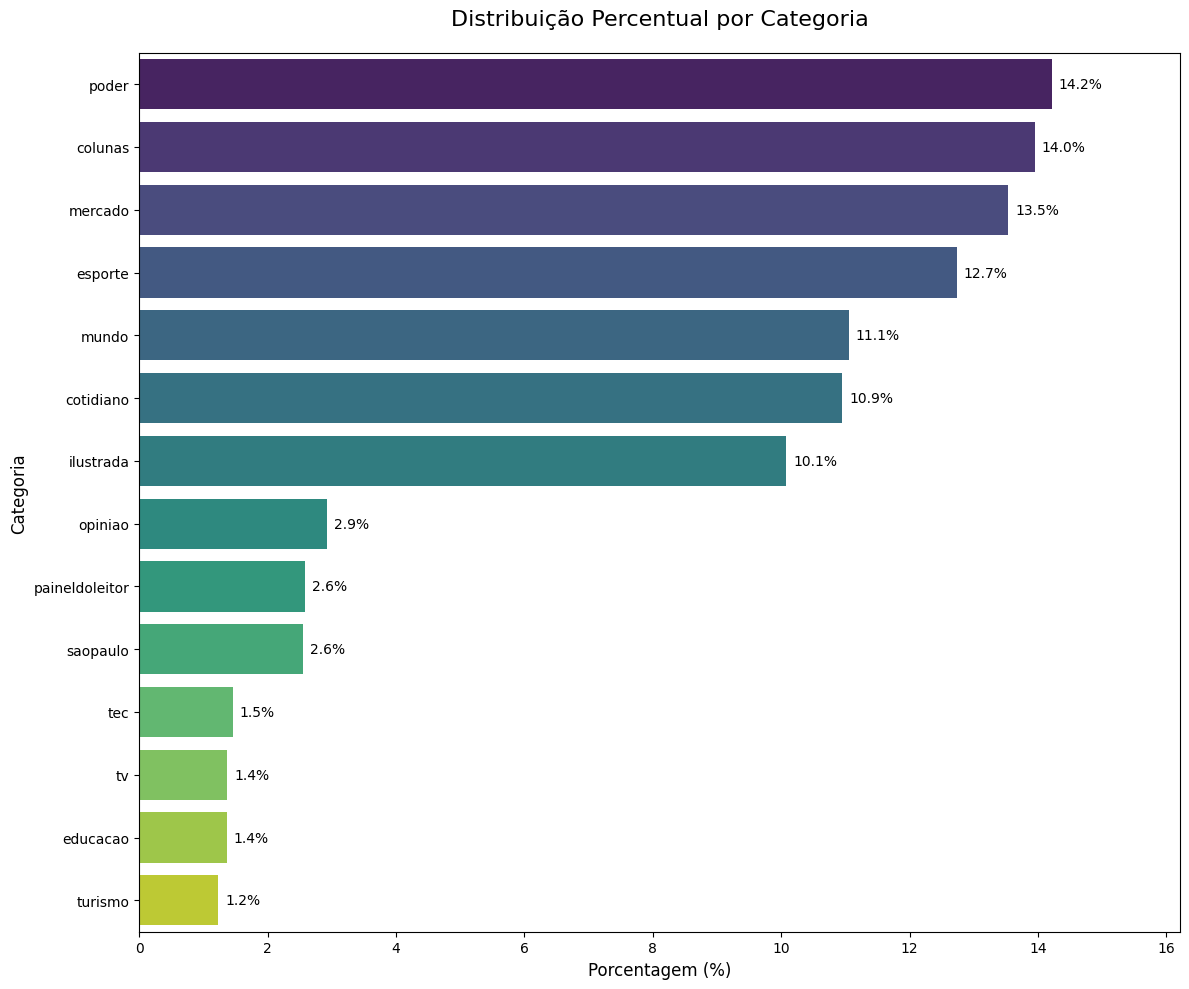

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.container import BarContainer

# 1. Calculando as porcentagens
total = len(df)
contagem = df['category'].value_counts().reset_index()
contagem.columns = ['category', 'quantidade']
contagem['porcentagem'] = (contagem['quantidade'] / total) * 100

# 2. Criando o gráfico
plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=contagem,
    y='category',
    x='porcentagem',
    hue='category',
    palette='viridis',
    legend=False
)

# 3. Adicionando os rótulos de porcentagem ao final de cada barra
for i in ax.containers:
    if isinstance(i, BarContainer):
        ax.bar_label(i, fmt='%.1f%%', padding=5)

# Configurações visuais
plt.title('Distribuição Percentual por Categoria', fontsize=16, pad=20)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.xlim(0, contagem['porcentagem'].max() + 2) # Dá um espaço extra para o texto não sumir

plt.tight_layout()
plt.show()

#### 2.5 Removendo categorias que constam uma recorrencia muito baixar para a modelagem

In [7]:
frequencia_categorias = df['category'].value_counts(normalize=True)

valida_categorias = frequencia_categorias[frequencia_categorias > 0.01].index # categorias com mais de 1% dos dados
df = df[df['category'].isin(valida_categorias)] # filtra o DataFrame para manter apenas as categorias válidas
df.info()

<class 'pandas.DataFrame'>
Index: 154950 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   title        154950 non-null  str           
 1   text         154950 non-null  str           
 2   date         154950 non-null  datetime64[us]
 3   category     154950 non-null  str           
 4   subcategory  28306 non-null   str           
 5   link         154950 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 8.3 MB
